# Forecast California Housing Prices

The data set being used is derived from the 1990 U.S. census.

The features are:

    - MedInc        median income in block group

    - HouseAge      median house age in block group

    - AveRooms      average number of rooms per household

    - AveBedrms     average number of bedrooms per household

    - Population    block group population

    - AveOccup      average number of household members

    - Latitude      block group latitude

    - Longitude     block group longitude

They are all numerical and the target variable is the median house value

for California districts, expressed in hundreds of thousands of dollars ($100,000).

In [30]:
# Import libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import optuna
from torch.utils.data import DataLoader, TensorDataset
# Dataset
from sklearn.datasets import fetch_california_housing

Applying random seeds to the models means they can be rerun and achieve

identical results each time.

In [31]:
np.random.seed(50)
torch.manual_seed(50)

I am now importing the dataset as a dataframe. The data is originally in a

bunch format, but it's easier for us to analyse data in a dataframe format.

In [32]:
# Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

**Questions**

* What is a `Bunch`?
* What is the default type for `data`?
* What is the default type for `target`?

**Answers**

1. A bunch object is a container that lets you access dictionary keys and

attributes using a dot notation instead of a bracket notation. So if I have

a dictionary called "house" with a key called "rooms" I can print it with

print(house.room) instead of print(house['room']).

2. The default type for 'data' is a pandas object. It's 20,640 rows of 8

features in order.

3. The default type for 'target' is also a pandas object. It's one column of

20,640 rows.

# Data cleaning and preprocessing

To begin with I am going to check the data for any issues in formatting.

Given that this is training data from sklearn it should be clean, but I will

check to make sure.

The first test is to check if there are any null values, and there aren't in

this instance.

In [33]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


The next step is to check the data set for duplicates.

As can be seen below there are no duplicate rows in the data.

In [34]:
print(df.duplicated().sum())

0


The next thing to check is the distribution of the data.

Beginning with looking at a boxplot of the data, 2 things are clear:

A) There are some outliers in the data set, most clearly for population

B) That scaling will be required as the scale of the population figures

dwarfs the others.

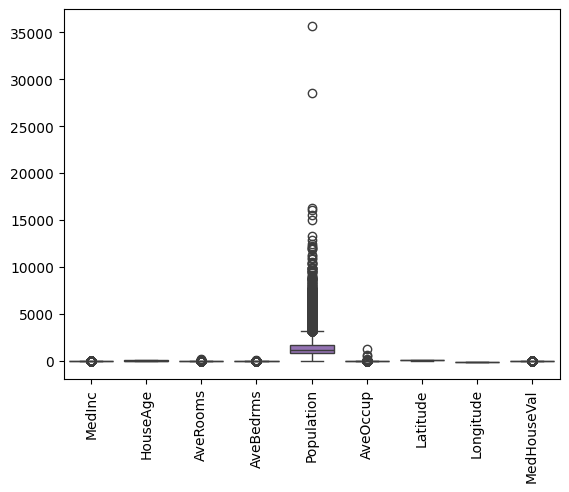

In [35]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

To deal with the outliers I am going to run an Isolation Forest on the data

to remove the top 5% of outliers.

In [36]:
iso = IsolationForest(contamination=0.05, random_state=41)
outlier_labels = iso.fit_predict(df.select_dtypes(include=[np.number]))

# -1 = outlier, 1 = inlier
df_clean = df[outlier_labels == 1]

print(f"Original shape:  {df.shape}")
print(f"Cleaned shape:   {df_clean.shape}")
print(f"Outliers removed: {df.shape[0] - df_clean.shape[0]}")

Original shape:  (20640, 9)
Cleaned shape:   (19608, 9)
Outliers removed: 1032


This has removed 1,032 outliers from the data set.

Looking now at the distribution of the data most of the distributions

look to be fairly normal apart from.

A) AveOccup appears to be very skewed towards the low-end occupancies

B) The Median House values has a spike in the $500K range.

From investigating the matter it appears that the median house prices were

capped at $500K, which means while other features were not capped the target

data was which could impact results in the training.


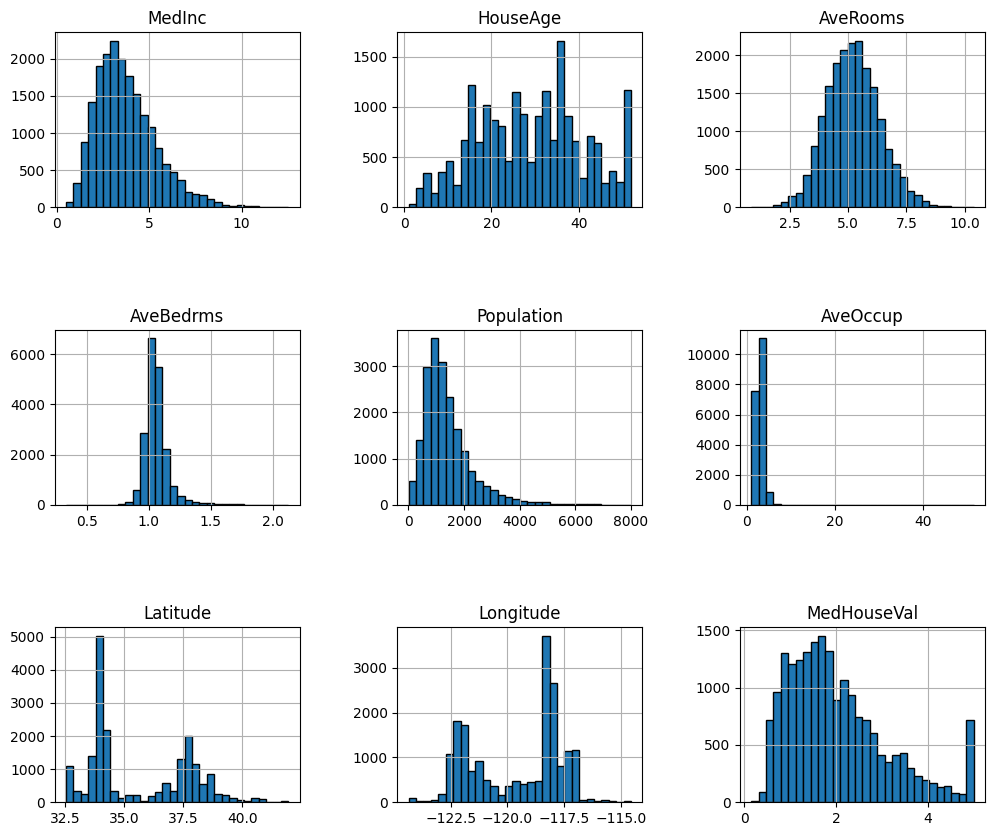

In [37]:
df_clean.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

To remove these outliers I am going to remove any houses with a value of

$500K and houses with an occupancy of over 10 people.

In [38]:
df_clean = df[df['MedHouseVal'] < 5.0]
df_clean = df_clean[df_clean['AveOccup'] < 10]

We are now ready to create the tensors for the data to train the model.

The features data set is the independent data, detailed at the top and the

targets is the median house prices.

Below I am rescaling the data using a MinMaxScaler, this proportionally

scales the data and prevents features with larger absolute scales from

dominating the model.

In [39]:
features = df_clean.drop('MedHouseVal', axis=1)
targets = df_clean[['MedHouseVal']].values.astype(float).reshape(-1, 1)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

features_normalized = feature_scaler.fit_transform(features)
targets_normalized = target_scaler.fit_transform(targets)

We are now ready to use the create_sequences function that generates

sequences of data and targets. This is preparing the data in a format

the model can train on.

The below formula is stating that the X is a list of 20 values from the

features data set and y is the 1st value after that from the test data.

E.g. if the x values are from 1-20, the y would be the 21st test value.

The sequence length has been set as 20 so each X sample will always be 20

characters long.

In [40]:
def create_sequences(data, targets, seq_length):
   X, y = [], []
   for i in range(len(data) - seq_length):
       X.append(data[i:i+seq_length])
       y.append(targets[i+seq_length])
   return np.array(X), np.array(y)


seq_length = 20
X, y = create_sequences(features_normalized,
                        targets_normalized, seq_length)

We now need to split the data set into training data set and test data set.

Below the data has been split 67% for training and 33% for testing.

In [41]:
train_size = int(len(X) * 0.67)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

I am now converting the data sets to tensors that the LSTM and GRU models

can read.

In [42]:
# Convert numpy arrays to PyTorch tensors with float32 data type
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

The 2 models we are going to use for training the data are the LSTM and GRU

models. Both models have been designed to solve for the vanishing gradient

issue in RNN's but approach the situation in a slightly different manner.

When gradients get incredibly small when the models are being trained this

means the updates to the weights each time become incredibly small which

impacts the models ability to learn.

The vanishing gradient issue can be down to a few main reasons:

i) Activation Saturation: In the below diagram for the Sigmoid curve you can

see that it will convert any number negative or positive to a number between

0 and 1. Once it gets either too large or too negative the gradient of the

curve becomes close to zero and the changes in the weights each change will

become very small.

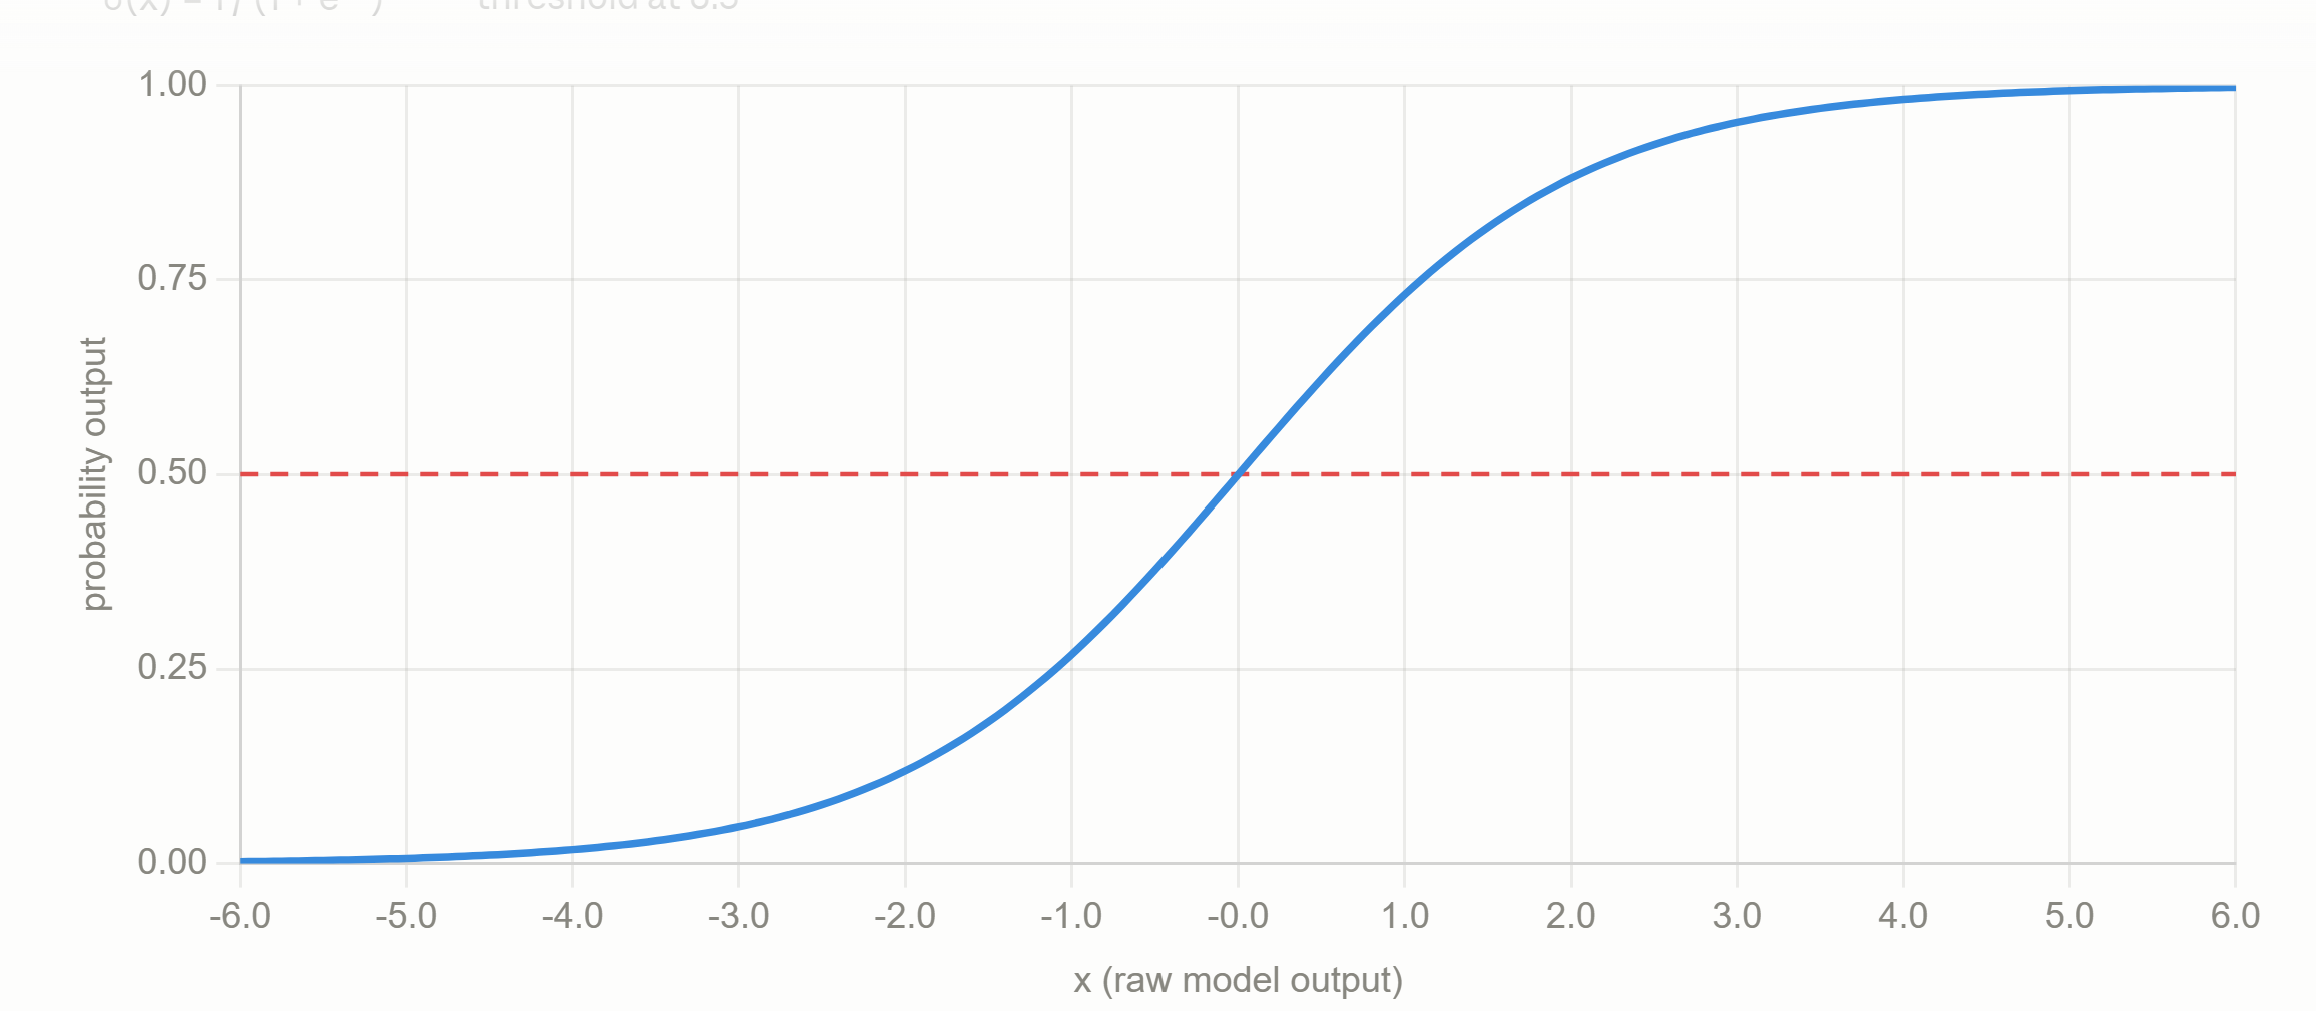

ii) Sequence Length: Specifically for RNN's using Back Propagation Through

Time the models will begin to converge to either 0 or 1 the more steps that

are included.

At each time step, the gradient is multiplied by the weight matrix W (the recurrent weights)

and the derivative of the activation function.  So for a sequence of T steps, the gradient

involves

∂L/∂h₀ ∝ W^T × (activation derivatives)^T

The greater the number of steps the more a combined recurrent weight and

derivative of the activation function under 1 converges to zero.

Other factors such as bad settings of initial weights can impact the model

too.
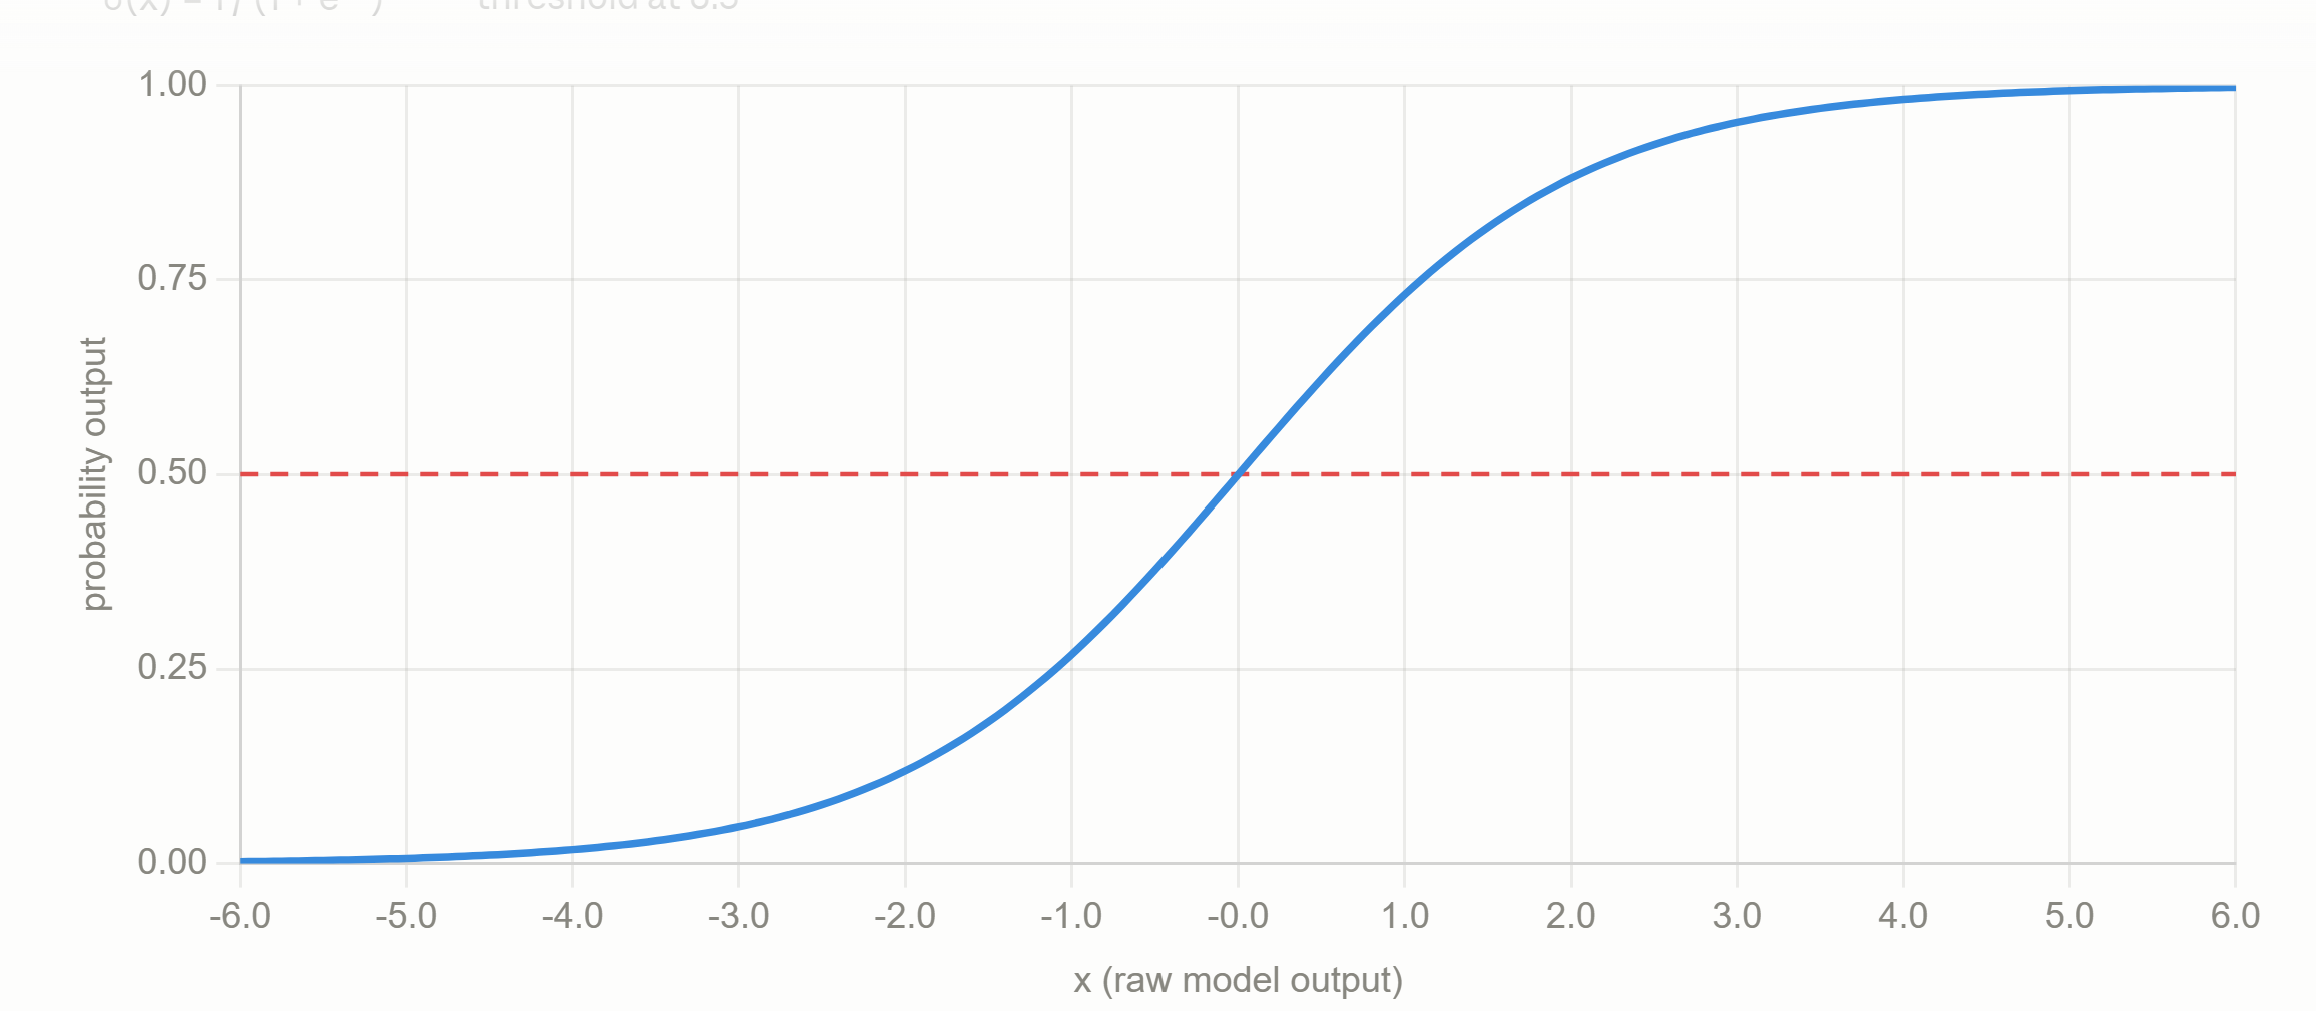
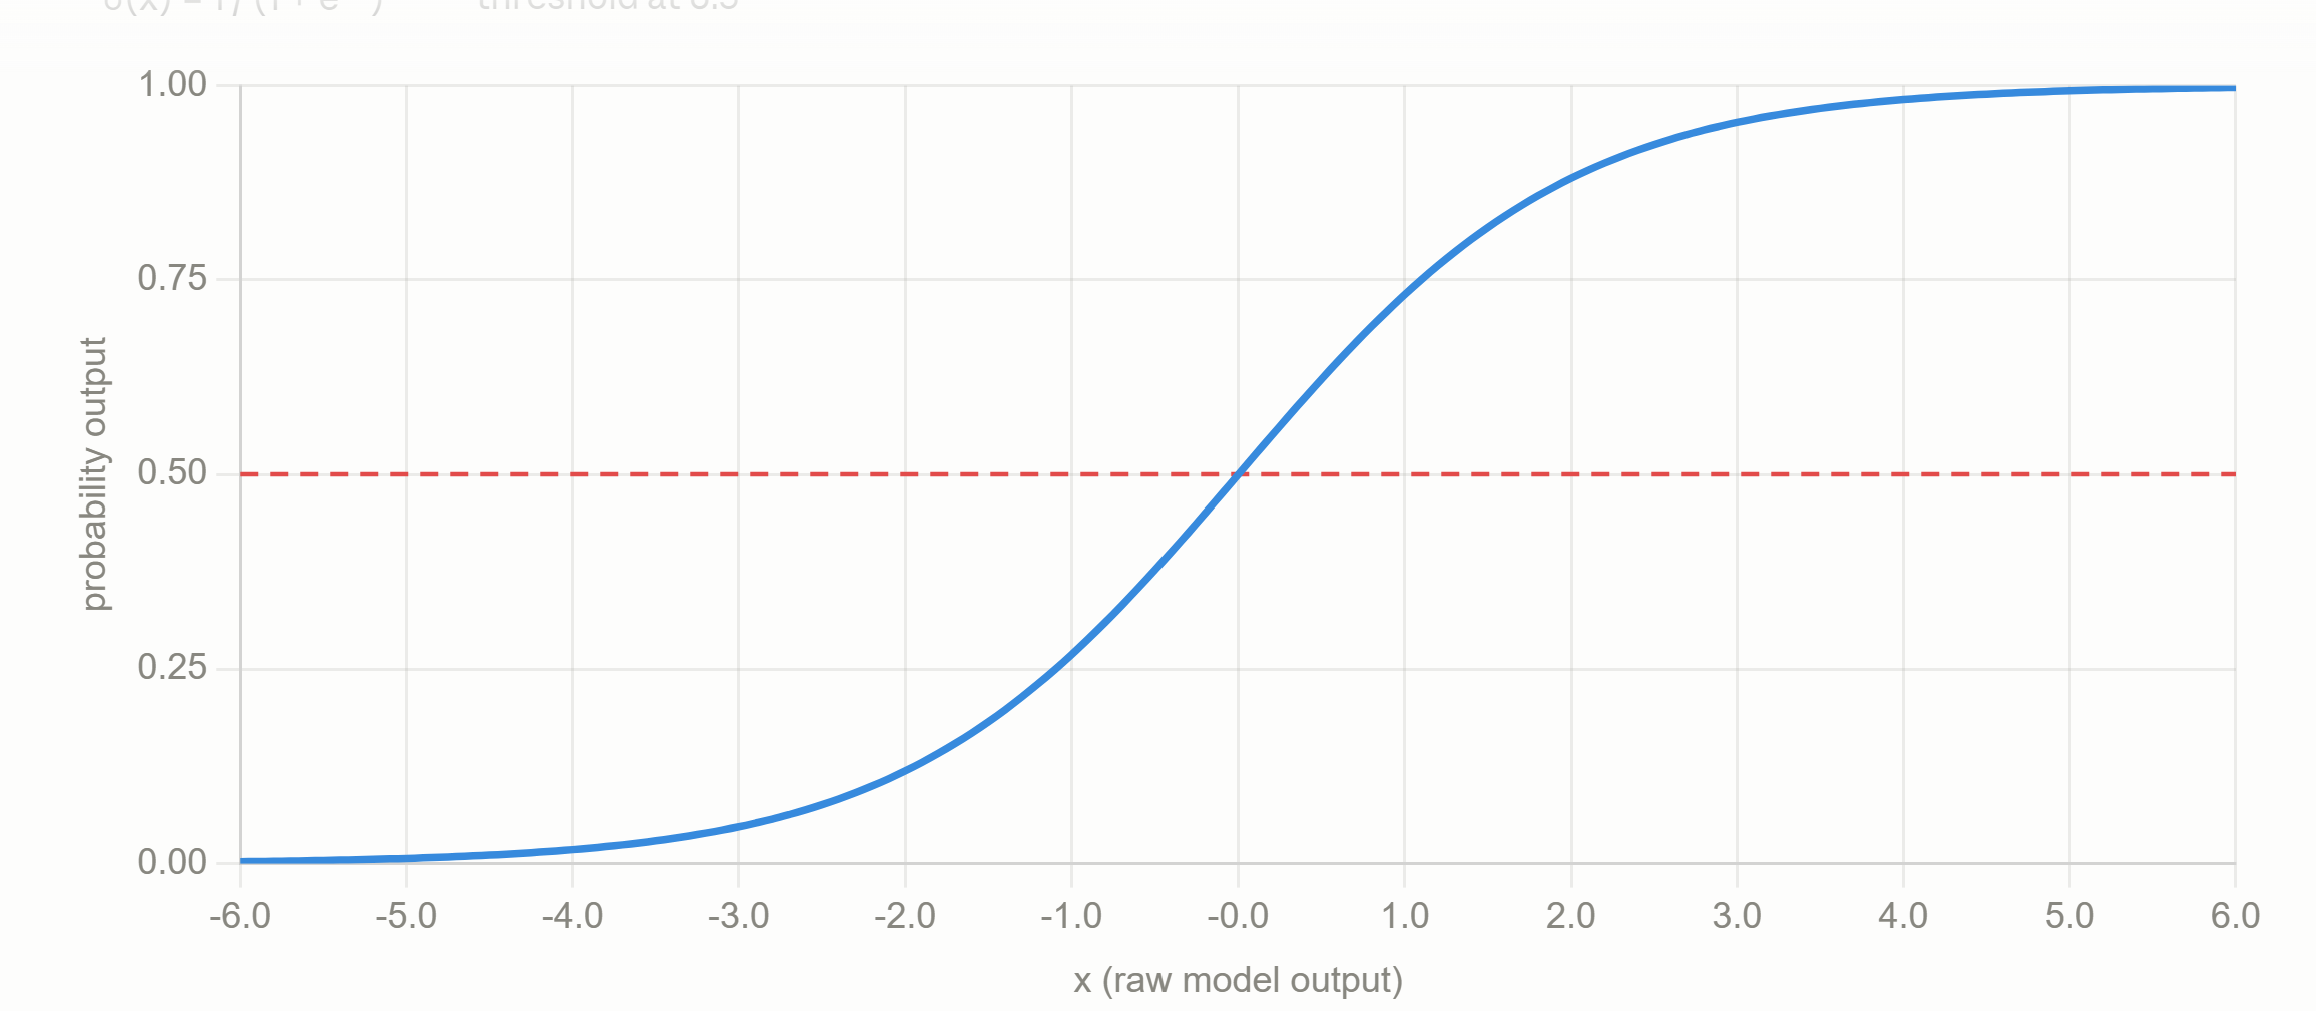

# LSTM model

The LSTM (Long Short Term Memory) model: Handles the issue of vanishing

gradient by using 3 gates.

i) Forget gate - This decides which information from the previous cell

be forgotten.

f_t = σ(W_f · [h_{t-1}, x_t] + b_f)

It uses the previous hidden state and current input combined

and is passed through a sigmoid function. This means the value is multiplied

by the sigmoid function value that is between 0 and 1. If the sigmoid

function output is 0 it will be completely forgotten, if it's 1 it will be

100% retained and values between that will be based on the sigmoid value e.g.

a value of x with a sigmoid value of 0.7, you will have an output of 0.7x.

ii) Input gate - Regulates what new information should be added to the cell

state, it works with 2 sections combined.

a) A sigmoid function: i_t = σ(W_i · [h_{t-1}, x_t] + b_i)

Which decides which values to update.

b) a tanh function: C̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)

Which creates a vector of new candidate values that could be added to the

state.

c) Cell state update: This is where the cell state is updated by combining

the previous cell state scaled by the forget gate and the new candidate

values scaled by the input gate.

C_t = (f_t × C_{t-1}) + (i_t × C̃_t)

iii) Output gate - The final part is the output gate which decides what the

next hidden state should be.

o_t = σ(W_o · [h_{t-1}, x_t] + b_o)

h_t = o_t × tanh(C_t)

The above pair of equations are used. It uses the current cell state

filtered through the tanh function to ensure the values are between -1 and 1

and it is then scaled by the output gate. This decides which parts of

the cell state will be output as the hidden state.

Before we instantiate the model we need to implement the model class

with configurable input size, hidden size, output size, and number of layers.

In [43]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        """ Defines an LSTM-based neural network model with one LSTM layer and
            one fully connected layer for sequence prediction tasks. """
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.fc(output[:, -1, :])
        return output

We next define the hyperparameters to be used by the training model.

Input size is 8 given that's how many features we have and output is 1 as we

want a single numerical prediction. The other hyperparameters can be tuned

to achieve the best results.

The learning rate, hidden size and number of epochs have been covered in

before but the new feature for LSTM is the l2_penalty.

The L2 Regularization Parameter (also called weight decay) is a

regularization technique that penalizes very large weights by adding a

a penalty term to the loss function.

Total Loss = Original Loss + λ × Σ(w²)

For the above lambda is the l2_penalty and Σ(w²) is the sum of all the

squared weights in the model. The effect is that it keeps the weights

smaller and more distributed rather than letting any one weight get too big.

In [44]:
# Define hyperparameters for the model training
input_size = 8
hidden_size = 50  # Number of features in the hidden state
output_size = 1
num_layers = 2  # Number of LSTM layers
learning_rate = 0.001  # Learning rate
num_epochs = 100
l2_penalty = 0.01  # L2 regularization parameter

We are now ready to instantiate the LTSM model.

We're using a loss function (criterion) of Mean Square Error.

This calculates the difference from the true value, squares it and averages

across all samples.

The optimizer we are using is Adam as it's adaptive learning rate tracks the

magnitude of past gradients and scales the learning rate individually per

parameter. Within the optimizer we can apply the l2_penalty as well as

learning rate defined earlier.

In [45]:
# Instantiate LSTM model, define loss function, and optimizer

model = LSTMModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,
                       weight_decay=l2_penalty)

The training loop is implemented for 100 epochs.

The model does improve the loss rate overall but there is diminishing

returns after 53 epochs in this example as the loss rate plateaus.

It finishes on a loss rate of 0.0378.

In [46]:
# Training loop for the LSTM model
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 0.1258
Epoch [2/100], Loss: 0.1149
Epoch [3/100], Loss: 0.1047
Epoch [4/100], Loss: 0.0952
Epoch [5/100], Loss: 0.0864
Epoch [6/100], Loss: 0.0782
Epoch [7/100], Loss: 0.0708
Epoch [8/100], Loss: 0.0641
Epoch [9/100], Loss: 0.0580
Epoch [10/100], Loss: 0.0528
Epoch [11/100], Loss: 0.0483
Epoch [12/100], Loss: 0.0447
Epoch [13/100], Loss: 0.0419
Epoch [14/100], Loss: 0.0399
Epoch [15/100], Loss: 0.0387
Epoch [16/100], Loss: 0.0381
Epoch [17/100], Loss: 0.0380
Epoch [18/100], Loss: 0.0382
Epoch [19/100], Loss: 0.0386
Epoch [20/100], Loss: 0.0389
Epoch [21/100], Loss: 0.0392
Epoch [22/100], Loss: 0.0393
Epoch [23/100], Loss: 0.0392
Epoch [24/100], Loss: 0.0390
Epoch [25/100], Loss: 0.0387
Epoch [26/100], Loss: 0.0384
Epoch [27/100], Loss: 0.0382
Epoch [28/100], Loss: 0.0380
Epoch [29/100], Loss: 0.0378
Epoch [30/100], Loss: 0.0378
Epoch [31/100], Loss: 0.0378
Epoch [32/100], Loss: 0.0379
Epoch [33/100], Loss: 0.0381
Epoch [34/100], Loss: 0.0383
Epoch [35/100], Loss: 0

Now we are going to use the trained model to generate predictions using the

test set. Given that the data was originally scaled before being processed

we need to reverse that process to generate an output comparable to the

target data in the test data set.

In [47]:
## Prediction and evaluation
# Predicting with the model using test data and inverting the scaling of predictions
with torch.no_grad():
    y_pred = model(X_test_tensor)

y_pred_inv = target_scaler.inverse_transform(y_pred.numpy())
y_test_inv = target_scaler.inverse_transform(y_test)

print("Predicted values:", y_pred_inv.squeeze())

Predicted values: [1.846325  1.84729   1.8414016 ... 1.7699056 1.7663717 1.76349  ]


Finally, we calculate the MSE and RMSE to see how accurate the predictions

were vs the actual target figures from the data set.



In [48]:
# Calculate Mean Squared Error between true and predicted values
mse = mean_squared_error(y_test_inv, y_pred_inv.squeeze())
print(f"Mean Squared Error: {mse:.4f}")
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.4f}')

Mean Squared Error: 1.0422
RMSE: 1.0209


The RMSE is 1.0209, or $102,090 and the average of the target data set is

$206,000. This means that the error is roughly 50% of the average house price

which is fairly high. I am going to run the Optuna library at the bottom to

tune the hyperparameters, but first we are going to run the GRU model using the

same parameters to compare results.

# GRU model

The GRU architecture modifies the LSTM design by combining the input and

forget gates into a single update gate and removing the output gate entirely.

This results in a model with fewer parameters than LSTM, as it simplifies

the gating mechanism without compromising the networks ability to capture

dependencies in sequence data. This speeds up training and is

computationally more efficient but does mean you have fewer hyperparameters

available to fine tune to get the optimum performance.

We are using the same data set and hyperparameters defined for the LSTM model

for the GRU Model and below are creating the GRU Model class.

In [49]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.gru(x)
        output = self.fc(output[:, -1, :])
        return output

As per with the LSTM model we are instantiating the GRU model and using

Mean Square Error loss function and Adam optimizer.

In [50]:
# Instantiate GRU model, and define loss function and optimizer

model = GRUModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate, weight_decay=l2_penalty)

With the same hyperparameters as the LSTM model used it has achieved a

marginally better performance. The model finishes with a loss rate of 0.0324

and continues to improve further into the 100 epochs.

Although it's not guaranteed that GRU will outperform LSTM every time a

reason it could have performed better in this instance is:

A) GRU has fewer parameters so has a lower risk of overfitting.

B) GRU converges faster and more cleanly under generic settings on a smaller

data set. The LSTM model is more likely to perform better on a larger data set

with tuned hyperparamters on a more complex data set.

In [51]:
# Training loop for the GRU model
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 0.2532
Epoch [2/100], Loss: 0.2091
Epoch [3/100], Loss: 0.1698
Epoch [4/100], Loss: 0.1354
Epoch [5/100], Loss: 0.1057
Epoch [6/100], Loss: 0.0810
Epoch [7/100], Loss: 0.0615
Epoch [8/100], Loss: 0.0475
Epoch [9/100], Loss: 0.0394
Epoch [10/100], Loss: 0.0368
Epoch [11/100], Loss: 0.0389
Epoch [12/100], Loss: 0.0436
Epoch [13/100], Loss: 0.0487
Epoch [14/100], Loss: 0.0523
Epoch [15/100], Loss: 0.0535
Epoch [16/100], Loss: 0.0523
Epoch [17/100], Loss: 0.0496
Epoch [18/100], Loss: 0.0461
Epoch [19/100], Loss: 0.0427
Epoch [20/100], Loss: 0.0399
Epoch [21/100], Loss: 0.0379
Epoch [22/100], Loss: 0.0368
Epoch [23/100], Loss: 0.0364
Epoch [24/100], Loss: 0.0366
Epoch [25/100], Loss: 0.0372
Epoch [26/100], Loss: 0.0379
Epoch [27/100], Loss: 0.0386
Epoch [28/100], Loss: 0.0392
Epoch [29/100], Loss: 0.0396
Epoch [30/100], Loss: 0.0397
Epoch [31/100], Loss: 0.0396
Epoch [32/100], Loss: 0.0392
Epoch [33/100], Loss: 0.0387
Epoch [34/100], Loss: 0.0381
Epoch [35/100], Loss: 0

In [52]:
# Predicting with the model using test data and inverting the scaling of predictions
with torch.no_grad():
    y_pred = model(X_test_tensor)

y_pred_inv = target_scaler.inverse_transform(y_pred.numpy())
y_test_inv = target_scaler.inverse_transform(y_test)

print("Predicted values:", y_pred_inv.squeeze())

Predicted values: [1.9757323 1.9860524 1.9460975 ... 1.5508325 1.5270566 1.5107127]


Above I have used the GRU model to predict values and below generated RMSE

values to determine the models accuracy. As expected, given the lower loss

rate for the GRU model, it has a lower RMSE of $98,280. This is still 48%

of the value of an average house price from the list but is better than

LSTM's result.

In [53]:
# Calculate Mean Squared Error between true and predicted values
mse = mean_squared_error(y_test_inv, y_pred_inv.squeeze())
rmse = np.sqrt(mse)
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

MSE: 0.9660
RMSE: 0.9828


# Impact of Regularisation Process

To isolate the impact of the regularization process in the models accuracy I'm

going to rerun the models without running the MinMaxScaler.

In [54]:
def create_sequences(data, targets, seq_length):
   X, y = [], []
   for i in range(len(data) - seq_length):
       X.append(data[i:i+seq_length])
       y.append(targets[i+seq_length])
   return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(features,targets, seq_length)

# Same train/test split being used as for the first test
train_size = int(len(X) * 0.67)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

With the updated tensors using unregularized data I am now going

to instantiate the LSTM model and start the training loop.

In [55]:
# Instantiate LSTM model, define loss function, and optimizer

model = LSTMModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,
                       weight_decay=l2_penalty)

# Training loop for the LSTM model
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 3.8031
Epoch [2/100], Loss: 3.6669
Epoch [3/100], Loss: 3.5333
Epoch [4/100], Loss: 3.4014
Epoch [5/100], Loss: 3.2706
Epoch [6/100], Loss: 3.1400
Epoch [7/100], Loss: 3.0099
Epoch [8/100], Loss: 2.8770
Epoch [9/100], Loss: 2.7433
Epoch [10/100], Loss: 2.6080
Epoch [11/100], Loss: 2.4709
Epoch [12/100], Loss: 2.3317
Epoch [13/100], Loss: 2.1901
Epoch [14/100], Loss: 2.0461
Epoch [15/100], Loss: 1.9001
Epoch [16/100], Loss: 1.7532
Epoch [17/100], Loss: 1.6073
Epoch [18/100], Loss: 1.4653
Epoch [19/100], Loss: 1.3310
Epoch [20/100], Loss: 1.2089
Epoch [21/100], Loss: 1.1038
Epoch [22/100], Loss: 1.0202
Epoch [23/100], Loss: 0.9599
Epoch [24/100], Loss: 0.9230
Epoch [25/100], Loss: 0.9083
Epoch [26/100], Loss: 0.9120
Epoch [27/100], Loss: 0.9267
Epoch [28/100], Loss: 0.9449
Epoch [29/100], Loss: 0.9619
Epoch [30/100], Loss: 0.9742
Epoch [31/100], Loss: 0.9805
Epoch [32/100], Loss: 0.9807
Epoch [33/100], Loss: 0.9759
Epoch [34/100], Loss: 0.9673
Epoch [35/100], Loss: 0

The loss value is higher than for the normalized data but that is to be

expected as it's a function of the scale of the data and the normalized data

has been reduced to a scale between 0 and 1. The loss rate does improve over

each epoch so the LSTM is improving in accuracy, albeit slowly.

In [56]:
# Predicting with the model using test data and inverting the scaling of predictions
with torch.no_grad():
    y_pred = model(X_test_tensor)

# Calculate Mean Squared Error between true and predicted values
mse = mean_squared_error(y_test, y_pred.squeeze())
rmse = np.sqrt(mse)
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

MSE: 0.9898
RMSE: 0.9949


The RMSE for the LSTM model with unregularized data is $99,490, which is

marginally better than when using the normalized data. The difference is fairly

small, but the impact of outliers can sometimes mean that normalizing a data

set crushes the rest of the figures and means that the trends are more

visible in the unregularized data.

Next applying the unregularized data set to the GRU model.

In [57]:
# Instantiate GRU model, and define loss function and optimizer

model = GRUModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate, weight_decay=l2_penalty)

# Training loop for the LSTM model
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 4.3947
Epoch [2/100], Loss: 3.6563
Epoch [3/100], Loss: 3.0006
Epoch [4/100], Loss: 2.5173
Epoch [5/100], Loss: 2.1193
Epoch [6/100], Loss: 1.7905
Epoch [7/100], Loss: 1.5214
Epoch [8/100], Loss: 1.3074
Epoch [9/100], Loss: 1.1444
Epoch [10/100], Loss: 1.0281
Epoch [11/100], Loss: 0.9537
Epoch [12/100], Loss: 0.9149
Epoch [13/100], Loss: 0.9048
Epoch [14/100], Loss: 0.9157
Epoch [15/100], Loss: 0.9397
Epoch [16/100], Loss: 0.9694
Epoch [17/100], Loss: 0.9982
Epoch [18/100], Loss: 1.0217
Epoch [19/100], Loss: 1.0372
Epoch [20/100], Loss: 1.0437
Epoch [21/100], Loss: 1.0416
Epoch [22/100], Loss: 1.0324
Epoch [23/100], Loss: 1.0177
Epoch [24/100], Loss: 0.9997
Epoch [25/100], Loss: 0.9801
Epoch [26/100], Loss: 0.9603
Epoch [27/100], Loss: 0.9401
Epoch [28/100], Loss: 0.9218
Epoch [29/100], Loss: 0.9079
Epoch [30/100], Loss: 0.9013
Epoch [31/100], Loss: 0.8998
Epoch [32/100], Loss: 0.9007
Epoch [33/100], Loss: 0.9021
Epoch [34/100], Loss: 0.9041
Epoch [35/100], Loss: 0

We can see from the above that as per the LSTM model the loss rates are higher

which is to be expected.

In [58]:
# Predicting with the model using test data and inverting the scaling of predictions
with torch.no_grad():
    y_pred = model(X_test_tensor)

# Calculate Mean Squared Error between true and predicted values
mse = mean_squared_error(y_test, y_pred.squeeze())
rmse = np.sqrt(mse)
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

MSE: 1.0000
RMSE: 1.0000


The GRU performed fractionally worse with the unregularized data achieving an

RMSE of $100,000. As per with LSTM the difference is very marginal.

The fact that the results are fairly similar when using normalized and raw

data can be down to 3 things.

i) The features are of similar scales already, which in our case is true

apart from the population feature.

ii) The model has learned to compensate through it's weights.

iii) Over a large enough data set it can overcome the inefficiency.

# Fine Tuning of Hyperparameters

The final part of this journal is to show the impact fine-tuning the

hyperparameters has on the results.

I am going to use the Optuna library that runs iterations of tests with

different hyperparameter configurations to identify the best configuration.

We can start with the LSTM model.

While we don't need to reimport the data we do need to create the sequence

with the normalized features.

I have split the data 67% for training and 33% for testing, but the test

data has been split into 2 sections. 16.5% is used as a valuation data set.

At the end of each epoch the model is run on the valuation data set without

updating the weights, producing a val loss accuracy. This loss value is

reported each time and the model prints the config at the bottom that has

the best val loss. The test data is then used for calculating the RMSE at the

end to make sure the model isn't overfit.

Optuna applies Bayesian inference on the hyperparameters that I have defined.

I have defined ranges for the hyperparameters that the model can randomly

choose combinations of in the first runs to identify what areas seem to

yield stronger results. After the initial runs it then focuses on those

stronger areas and runs the remaining tests optimizing the results in those

areas.

The code below finishes by using the tuned hyperparameters to train the

model and use the test data set to generate predictions which are compared

to the actual targets from the test data set to derive the MSE and RMSE values.

In [59]:
def create_sequences(data, targets, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(targets[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(features_normalized, targets_normalized, seq_length)

# Splits: 67% train, 16.5% val, 16.5% test — same as Optuna must see
train_size = int(len(X) * 0.67)
val_size = int(len(X) * 0.165)
# The train, val and test data sets are turned into tensors ready for use in
# the models.
X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)
X_val   = torch.tensor(X[train_size:train_size+val_size], dtype=torch.float32)
y_val   = torch.tensor(y[train_size:train_size+val_size], dtype=torch.float32)
X_test  = torch.tensor(X[train_size+val_size:], dtype=torch.float32)
y_test  = torch.tensor(y[train_size+val_size:], dtype=torch.float32)

# As per previous runs we use an input size of 8, 1 for each feature and an
# output of 1.
input_size = 8
output_size = 1
# We are creating a new class of the LSTM Model as this time we're adding
# the batch hyperparameter which will be tuned along with the others.
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])
# The train and evaluate function takes in all the hyperparameters each time
# to train the model and return a val loss.
def train_and_evaluate(hidden_size, num_layers, learning_rate, l2_penalty, num_epochs, batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False
    )
    #This is where we instantiate the model and define the loss function and
    # optimizer. We are using the same as for previous model training runs.
    model = LSTMModel(input_size, hidden_size, output_size, num_layers)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

    # The best_val_loss is set and infinite so any loss after that will be
    # an improvement. The patience loss means that a run goes 10 epochs
    # without improving it will stop running and output the best run from
    # the epochs it has done.
    best_val_loss = float('inf')
    patience, patience_counter = 10, 0
    best_state = None
    # Training loop for the LSTM model
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        # This loop is for finding the best val loss, the best combination
        # of hyperparameters from the test runs.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss
# The hyperparameters below have been set in a range that the model can
# choose values between, except for batch size where a list has been
# provided that the model can select from.
def objective(trial):
    hidden_size  = trial.suggest_int('hidden_size', 32, 256)
    num_layers   = trial.suggest_int('num_layers', 1, 3)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    l2_penalty   = trial.suggest_float('l2_penalty', 1e-5, 1e-2, log=True)
    num_epochs   = trial.suggest_int('num_epochs', 50, 200)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])

    _, val_loss = train_and_evaluate(
        hidden_size, num_layers, learning_rate, l2_penalty, num_epochs, batch_size
    )
    return val_loss
# As the metric we are looking to optimize is val loss we're looking to find
# the configuration with the lowest val loss so we tell its aim is to
# minimize the value. We're also setting it to perform 50 trial runs in
# order to find the best fit.
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best trial:", study.best_trial.params)

# Final evaluation on test set using best params
best = study.best_trial.params
model, _ = train_and_evaluate(**best)

model.eval()
with torch.no_grad():
    y_pred = model(X_test)

y_pred_inv = target_scaler.inverse_transform(y_pred.numpy())
y_test_inv = target_scaler.inverse_transform(y_test.numpy())

mse = mean_squared_error(y_test_inv, y_pred_inv.squeeze())
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

[I 2026-05-17 19:31:14,832] A new study created in memory with name: no-name-f3cf23fe-2d1d-4f2f-8bbd-01792517dbe8
[I 2026-05-17 19:38:06,486] Trial 0 finished with value: 0.025052377954125404 and parameters: {'hidden_size': 203, 'num_layers': 3, 'learning_rate': 0.0004225850500073141, 'l2_penalty': 1.98553023081878e-05, 'num_epochs': 200, 'batch_size': 64}. Best is trial 0 with value: 0.025052377954125404.
[I 2026-05-17 19:39:43,071] Trial 1 finished with value: 0.02460453473031521 and parameters: {'hidden_size': 240, 'num_layers': 2, 'learning_rate': 0.006021752088902022, 'l2_penalty': 0.00015328713236868358, 'num_epochs': 175, 'batch_size': 128}. Best is trial 1 with value: 0.02460453473031521.
[I 2026-05-17 19:40:13,515] Trial 2 finished with value: 0.04694706201553345 and parameters: {'hidden_size': 218, 'num_layers': 3, 'learning_rate': 0.005221286264738111, 'l2_penalty': 0.007874236429628631, 'num_epochs': 89, 'batch_size': 128}. Best is trial 1 with value: 0.02460453473031521.
[

Best trial: {'hidden_size': 59, 'num_layers': 1, 'learning_rate': 0.0003557100738340901, 'l2_penalty': 0.00014382068964374867, 'num_epochs': 190, 'batch_size': 128}
MSE:  0.3708
RMSE: 0.6089


For LSTM using the optimum configuration calculated by the Optuna library

the model achieved a RMSE of $60,890 which is 29.6% of the average house

value that is markedly lower than where we started at $102,090.

We still only used a hidden size of 59 and 1 layer but the larger number of

epochs and batch size combined with a lower learning rate achieved a better

configured model.

We now look at the GRU model. We are running the same code as above for

tuning the hyperparameters for the GRU model, but changing the model class

in the middle of the code.

In [60]:
# Sequences
def create_sequences(data, targets, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(targets[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(features_normalized, targets_normalized, seq_length)

# Splits: 67% train, 16.5% val, 16.5% test
train_size = int(len(X) * 0.67)
val_size = int(len(X) * 0.165)
# Data sets are converted to tensors
X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)
X_val   = torch.tensor(X[train_size:train_size+val_size], dtype=torch.float32)
y_val   = torch.tensor(y[train_size:train_size+val_size], dtype=torch.float32)
X_test  = torch.tensor(X[train_size+val_size:], dtype=torch.float32)
y_test  = torch.tensor(y[train_size+val_size:], dtype=torch.float32)

input_size = 8
output_size = 1

# We this time define the GRU model class instead of LSTM.
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.gru(x)        # GRU returns (output, h_n) — no cell state
        return self.fc(output[:, -1, :])


def train_and_evaluate(hidden_size, num_layers, learning_rate, l2_penalty, num_epochs, batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False
    )
    #This is where we instantiate the GRU model, define the loss function
    # and optimizer.
    model = GRUModel(input_size, hidden_size, output_size, num_layers)  # GRUModel
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

    best_val_loss = float('inf')
    patience, patience_counter = 10, 0
    best_state = None
    # We train the model and find the lowest val loss value.
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss

# The hyperparameter ranges used are the same as for LSTM but I've used
# decimals in some places instead of log values.
def objective(trial):
    hidden_size   = trial.suggest_int('hidden_size', 32, 256)
    num_layers    = trial.suggest_int('num_layers', 1, 3)
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.01)
    l2_penalty    = trial.suggest_float('l2_penalty', 0.00001, 0.01)
    num_epochs    = trial.suggest_int('num_epochs', 50, 200)
    batch_size    = trial.suggest_categorical('batch_size', [32, 64, 128])

    _, val_loss = train_and_evaluate(
        hidden_size, num_layers, learning_rate, l2_penalty, num_epochs, batch_size
    )
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best trial:", study.best_trial.params)

# We now train the model using the hyperparameters from the best val loss
# run on the test data and compare the results to the actual target values
# to get MSE and RMSE values.
best = study.best_trial.params
model, _ = train_and_evaluate(**best)

model.eval()
with torch.no_grad():
    y_pred = model(X_test)

y_pred_inv = target_scaler.inverse_transform(y_pred.numpy())
y_test_inv = target_scaler.inverse_transform(y_test.numpy())

mse = mean_squared_error(y_test_inv, y_pred_inv.squeeze())
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

[I 2026-05-17 20:24:39,663] A new study created in memory with name: no-name-fd89c509-504e-4f73-9930-13010c6b8439
[I 2026-05-17 20:25:12,311] Trial 0 finished with value: 0.059590402990579605 and parameters: {'hidden_size': 179, 'num_layers': 2, 'learning_rate': 0.005826744283155866, 'l2_penalty': 0.006091212773296431, 'num_epochs': 50, 'batch_size': 64}. Best is trial 0 with value: 0.059590402990579605.
[I 2026-05-17 20:25:57,687] Trial 1 finished with value: 0.04597041755914688 and parameters: {'hidden_size': 179, 'num_layers': 2, 'learning_rate': 0.009187844016808843, 'l2_penalty': 0.007777096592649878, 'num_epochs': 190, 'batch_size': 64}. Best is trial 1 with value: 0.04597041755914688.
[I 2026-05-17 20:27:39,951] Trial 2 finished with value: 0.050080306828022 and parameters: {'hidden_size': 232, 'num_layers': 3, 'learning_rate': 0.0022900024732664293, 'l2_penalty': 0.007486123292291405, 'num_epochs': 174, 'batch_size': 128}. Best is trial 1 with value: 0.04597041755914688.
[I 202

Best trial: {'hidden_size': 134, 'num_layers': 1, 'learning_rate': 0.00022753352172401396, 'l2_penalty': 2.9408909037705e-05, 'num_epochs': 126, 'batch_size': 128}
MSE:  0.3857
RMSE: 0.6211


As with the LSTM model when using the tuned hyperparameters the results are

considerably improved from the first run, and we have an RMSE of $62,110 vs

the original $99,490. The result was achieved with a higher hidden size of

134, and similar number of epochs and batch size the LSTM version.

**Note:** The California housing dataset was sourced by scikit-learn from the StatLib repository: https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

**Reference**  
Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. Statistics & Probability Letters, 33(3), 291-297.